# Census Income con PyTorch: multivariable, regularización, optimización y métricas


Objetivo: construir una red neuronal en PyTorch para clasificar la ocupación de una persona usando todas las variables del censo.

Incluye:
- regularización con `weight_decay`, `Dropout` y `BatchNorm`
- optimización con `SGD`, `Momentum`, `Adam` y scheduler
- métricas multiclase como en el notebook 08: `accuracy`, matriz de confusión, `precision`, `recall`, `F1` y `ROC-AUC`

## 1. Librerías y configuración

Si tu entorno no tiene alguna dependencia, descomenta la línea de instalación.

In [15]:
# %pip install numpy pandas scikit-learn matplotlib torch

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 2. Carga y preprocesamiento

La red no trabaja directamente con categorías de texto, así que transformamos las variables numéricas y categóricas por separado.

En este modelo el target es multiclase: `occupation`. Por eso usamos `LabelEncoder` y métricas promediadas (`macro` y `weighted`).

In [16]:
df = pd.read_csv('adult.csv').copy()
df.columns = [c.strip() for c in df.columns]

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()

df = df.replace('?', np.nan)
target_col = 'occupation'

if target_col not in df.columns:
    raise ValueError('No se encontró la columna occupation en adult.csv')

df = df.dropna(subset=[target_col]).copy()

X = df.drop(columns=[target_col])
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[target_col].astype(str))
class_names = label_encoder.classes_
num_classes = len(class_names)

print('Shape X:', X.shape)
print('Número de clases:', num_classes)
print('Clases:', list(class_names))

Shape X: (30718, 14)
Número de clases: 14
Clases: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ]
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

if hasattr(X_train_t, 'toarray'):
    X_train_t = X_train_t.toarray()
if hasattr(X_test_t, 'toarray'):
    X_test_t = X_test_t.toarray()

X_train_t = X_train_t.astype(np.float32)
X_test_t = X_test_t.astype(np.float32)
y_train_np = y_train.astype(np.int64)
y_test_np = y_test.astype(np.int64)

train_ds = TensorDataset(torch.from_numpy(X_train_t), torch.from_numpy(y_train_np))
test_ds = TensorDataset(torch.from_numpy(X_test_t), torch.from_numpy(y_test_np))

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

input_dim = X_train_t.shape[1]
class_counts = np.bincount(y_train_np, minlength=num_classes)

print('input_dim:', input_dim)
print('class distribution:', class_counts.tolist())

input_dim: 91
class distribution: [3016, 7, 3279, 3253, 795, 1096, 1602, 2636, 119, 3312, 519, 2920, 742, 1278]


## 3. Regularización

La regularización reduce el sobreajuste. En este modelo la aplicamos de tres formas:
- `weight_decay`: penaliza pesos grandes y hace la red más estable
- `Dropout`: apaga neuronas durante el entrenamiento para evitar dependencia excesiva
- `BatchNorm`: normaliza activaciones internas y acelera el entrenamiento

Eso suele bajar un poco la precisión de entrenamiento, pero mejora la capacidad de generalización.

In [18]:
class CensusBinaryMLP(nn.Module):
    def __init__(self, in_features, n_classes, hidden1=256, hidden2=128, dropout=0.0, batchnorm=False):
        super().__init__()
        layers = [nn.Linear(in_features, hidden1)]
        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden1))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden1, hidden2))
        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden2))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden2, n_classes))
        self.net = nn.Sequential(*layers)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

## 4. Optimización

La optimización es la forma en que la red ajusta sus pesos para minimizar el error.

Aquí compararemos dos enfoques:
- `AdamW` sin regularización extra como referencia
- `AdamW` con `Dropout`, `BatchNorm` y `weight_decay` como versión regularizada

Con este target tan desbalanceado, una pérdida no ponderada suele dar mejor accuracy global que forzar demasiado las clases minoritarias.

In [19]:
def predict_proba_binary(model, loader):
    model.eval()
    probs = []
    truths = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            batch_probs = torch.softmax(logits, dim=1)
            probs.extend(batch_probs.detach().cpu().numpy().tolist())
            truths.extend(yb.detach().cpu().numpy().tolist())
    return np.array(truths), np.array(probs)

def fit_model(model, train_loader, test_loader, optimizer, epochs=20, scheduler=None, patience=0):
    criterion = nn.CrossEntropyLoss()
    history = {'epoch': [], 'train_loss': [], 'test_loss': [], 'test_accuracy': [], 'test_f1_macro': [], 'test_f1_weighted': [], 'test_auc_ovr_macro': []}
    best_state = None
    best_score = -np.inf
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        test_losses = []
        all_true = []
        all_probs = []

        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                probs = torch.softmax(logits, dim=1)
                test_losses.append(loss.item())
                all_true.extend(yb.detach().cpu().numpy().tolist())
                all_probs.extend(probs.detach().cpu().numpy().tolist())

        all_true = np.array(all_true)
        all_probs = np.array(all_probs)
        all_pred = np.argmax(all_probs, axis=1)

        train_loss = float(np.mean(train_losses))
        test_loss = float(np.mean(test_losses))
        test_acc = accuracy_score(all_true, all_pred)
        test_f1_macro = f1_score(all_true, all_pred, average='macro', zero_division=0)
        test_f1_weighted = f1_score(all_true, all_pred, average='weighted', zero_division=0)
        try:
            test_auc_ovr_macro = roc_auc_score(all_true, all_probs, multi_class='ovr', average='macro')
        except ValueError:
            test_auc_ovr_macro = np.nan

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_accuracy'].append(test_acc)
        history['test_f1_macro'].append(test_f1_macro)
        history['test_f1_weighted'].append(test_f1_weighted)
        history['test_auc_ovr_macro'].append(test_auc_ovr_macro)

        score = test_f1_macro
        if score > best_score:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if scheduler is not None:
            scheduler.step()

        print(f'Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | test_loss={test_loss:.4f} | acc={test_acc:.4f} | f1_macro={test_f1_macro:.4f} | auc_ovr_macro={test_auc_ovr_macro:.4f}')

        if patience and wait >= patience:
            print(f'Early stopping activado en epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

## 5. Experimento base y experimento regularizado

El experimento base usa un optimizador simple. El experimento regularizado usa técnicas combinadas de 05 y 06: Dropout, BatchNorm, weight decay, Adam, scheduler y early stopping.

In [20]:
baseline_model = CensusBinaryMLP(input_dim, num_classes, dropout=0.0, batchnorm=True).to(device)
baseline_optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=2e-3, weight_decay=1e-4)
baseline_model, baseline_history = fit_model(
    baseline_model, train_loader, test_loader, baseline_optimizer, epochs=20, patience=5
)

Epoch 01/20 | train_loss=1.9713 | test_loss=1.8943 | acc=0.3335 | f1_macro=0.2275 | auc_ovr_macro=0.7790
Epoch 02/20 | train_loss=1.8385 | test_loss=1.8590 | acc=0.3563 | f1_macro=0.2296 | auc_ovr_macro=0.7928
Epoch 03/20 | train_loss=1.8040 | test_loss=1.8569 | acc=0.3561 | f1_macro=0.2489 | auc_ovr_macro=0.7978
Epoch 04/20 | train_loss=1.7847 | test_loss=1.8686 | acc=0.3499 | f1_macro=0.2473 | auc_ovr_macro=0.7933
Epoch 05/20 | train_loss=1.7677 | test_loss=1.8740 | acc=0.3478 | f1_macro=0.2412 | auc_ovr_macro=0.8087
Epoch 06/20 | train_loss=1.7490 | test_loss=1.8678 | acc=0.3512 | f1_macro=0.2612 | auc_ovr_macro=0.7943
Epoch 07/20 | train_loss=1.7364 | test_loss=1.8895 | acc=0.3503 | f1_macro=0.2409 | auc_ovr_macro=0.7986
Epoch 08/20 | train_loss=1.7196 | test_loss=1.8960 | acc=0.3439 | f1_macro=0.2420 | auc_ovr_macro=0.7944
Epoch 09/20 | train_loss=1.7044 | test_loss=1.8899 | acc=0.3410 | f1_macro=0.2409 | auc_ovr_macro=0.7984
Epoch 10/20 | train_loss=1.6944 | test_loss=1.9095 | ac

In [21]:
regularized_model = CensusBinaryMLP(input_dim, num_classes, dropout=0.2, batchnorm=True).to(device)
regularized_optimizer = torch.optim.AdamW(
    regularized_model.parameters(), lr=1e-3, weight_decay=5e-4
)
regularized_scheduler = torch.optim.lr_scheduler.StepLR(regularized_optimizer, step_size=6, gamma=0.8)
regularized_model, regularized_history = fit_model(
    regularized_model, train_loader, test_loader, regularized_optimizer, epochs=20, scheduler=regularized_scheduler, patience=5
)

Epoch 01/20 | train_loss=2.1452 | test_loss=1.9036 | acc=0.3392 | f1_macro=0.2068 | auc_ovr_macro=0.7751
Epoch 02/20 | train_loss=1.9441 | test_loss=1.8737 | acc=0.3483 | f1_macro=0.2250 | auc_ovr_macro=0.7846
Epoch 03/20 | train_loss=1.9026 | test_loss=1.8602 | acc=0.3511 | f1_macro=0.2354 | auc_ovr_macro=0.7893
Epoch 04/20 | train_loss=1.8786 | test_loss=1.8505 | acc=0.3547 | f1_macro=0.2335 | auc_ovr_macro=0.7970
Epoch 05/20 | train_loss=1.8616 | test_loss=1.8446 | acc=0.3542 | f1_macro=0.2304 | auc_ovr_macro=0.7963
Epoch 06/20 | train_loss=1.8502 | test_loss=1.8419 | acc=0.3542 | f1_macro=0.2407 | auc_ovr_macro=0.7989
Epoch 07/20 | train_loss=1.8342 | test_loss=1.8439 | acc=0.3538 | f1_macro=0.2461 | auc_ovr_macro=0.8027
Epoch 08/20 | train_loss=1.8279 | test_loss=1.8393 | acc=0.3525 | f1_macro=0.2433 | auc_ovr_macro=0.8000
Epoch 09/20 | train_loss=1.8225 | test_loss=1.8394 | acc=0.3579 | f1_macro=0.2461 | auc_ovr_macro=0.8027
Epoch 10/20 | train_loss=1.8160 | test_loss=1.8343 | ac

## 6. Métricas

Las métricas no se usan para entrenar la red, sino para medir su calidad.

Aquí las dejamos separadas, como en el notebook 08, para que puedas ver claramente qué aporta cada una al modelo. En multiclase usaremos promedios `macro` y `weighted`.

In [22]:
def metric_accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def metric_precision(y_true, y_pred, average='macro'):
    return precision_score(y_true, y_pred, average=average, zero_division=0)

def metric_recall(y_true, y_pred, average='macro'):
    return recall_score(y_true, y_pred, average=average, zero_division=0)

def metric_f1(y_true, y_pred, average='macro'):
    return f1_score(y_true, y_pred, average=average, zero_division=0)

def metric_roc_auc(y_true, y_proba):
    try:
        return roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        return np.nan

def get_predictions(model, loader):
    y_true, y_proba = predict_proba_binary(model, loader)
    y_pred = np.argmax(y_proba, axis=1)
    return y_true.astype(int), y_pred.astype(int), y_proba

### Accuracy

Mide el porcentaje total de aciertos. En un problema multiclase como este puede verse bien aunque el modelo no capture bien todas las clases, por eso no debe usarse sola.

In [23]:
y_true_b, y_pred_b, y_proba_b = get_predictions(baseline_model, test_loader)
y_true_r, y_pred_r, y_proba_r = get_predictions(regularized_model, test_loader)

acc_base = metric_accuracy(y_true_b, y_pred_b)
acc_reg = metric_accuracy(y_true_r, y_pred_r)
print(f'Accuracy baseline: {acc_base:.4f}')
print(f'Accuracy regularizado: {acc_reg:.4f}')

Accuracy baseline: 0.3512
Accuracy regularizado: 0.3579


### Matriz de Confusión

Nos muestra cuántos casos de cada clase fueron clasificados correctamente o confundidos. Es útil para ver en qué ocupaciones el modelo falla más.

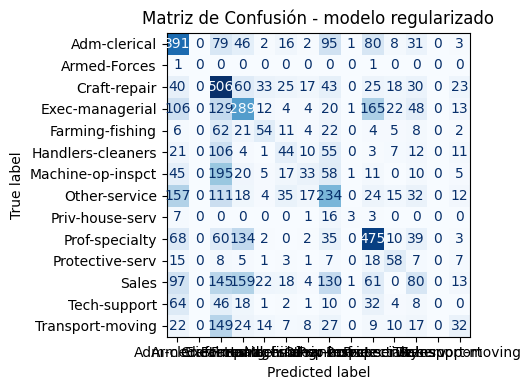

In [24]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    _, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(y_true_r, y_pred_r, 'Matriz de Confusión - modelo regularizado')

### Precision y Recall

Precision responde: de todo lo que el modelo predijo como una clase, cuántos realmente lo eran.
Recall responde: de todos los ejemplos reales de una clase, cuántos detectó el modelo.

En problemas multiclase y desbalanceados, estas métricas son más informativas que la accuracy.

In [25]:
prec_reg_macro = metric_precision(y_true_r, y_pred_r, average='macro')
rec_reg_macro = metric_recall(y_true_r, y_pred_r, average='macro')
prec_base_macro = metric_precision(y_true_b, y_pred_b, average='macro')
rec_base_macro = metric_recall(y_true_b, y_pred_b, average='macro')
prec_reg_weighted = metric_precision(y_true_r, y_pred_r, average='weighted')
rec_reg_weighted = metric_recall(y_true_r, y_pred_r, average='weighted')
prec_base_weighted = metric_precision(y_true_b, y_pred_b, average='weighted')
rec_base_weighted = metric_recall(y_true_b, y_pred_b, average='weighted')

print(f'Precision baseline macro: {prec_base_macro:.4f} | Recall baseline macro: {rec_base_macro:.4f}')
print(f'Precision regularizado macro: {prec_reg_macro:.4f} | Recall regularizado macro: {rec_reg_macro:.4f}')
print(f'Precision baseline weighted: {prec_base_weighted:.4f} | Recall baseline weighted: {rec_base_weighted:.4f}')
print(f'Precision regularizado weighted: {prec_reg_weighted:.4f} | Recall regularizado weighted: {rec_reg_weighted:.4f}')

Precision baseline macro: 0.3230 | Recall baseline macro: 0.2596
Precision regularizado macro: 0.2935 | Recall regularizado macro: 0.2636
Precision baseline weighted: 0.3414 | Recall baseline weighted: 0.3512
Precision regularizado weighted: 0.3359 | Recall regularizado weighted: 0.3579


### F1-Score

Resume precision y recall en un solo número. Es útil cuando quieres balance entre falsos positivos y falsos negativos. En multiclase suele reportarse con promedio `macro` y `weighted`.

In [26]:
f1_base_macro = metric_f1(y_true_b, y_pred_b, average='macro')
f1_reg_macro = metric_f1(y_true_r, y_pred_r, average='macro')
f1_base_weighted = metric_f1(y_true_b, y_pred_b, average='weighted')
f1_reg_weighted = metric_f1(y_true_r, y_pred_r, average='weighted')

print(f'F1 baseline macro: {f1_base_macro:.4f}')
print(f'F1 regularizado macro: {f1_reg_macro:.4f}')
print(f'F1 baseline weighted: {f1_base_weighted:.4f}')
print(f'F1 regularizado weighted: {f1_reg_weighted:.4f}')

F1 baseline macro: 0.2612
F1 regularizado macro: 0.2562
F1 baseline weighted: 0.3309
F1 regularizado weighted: 0.3281


### ROC-AUC

Mide la capacidad del modelo para separar las clases sin depender de un threshold fijo. Valores más cercanos a 1 indican mejor separación entre clases.

In [27]:
auc_base = metric_roc_auc(y_true_b, y_proba_b)
auc_reg = metric_roc_auc(y_true_r, y_proba_r)

print(f'ROC-AUC baseline OVR macro: {auc_base:.4f}')
print(f'ROC-AUC regularizado OVR macro: {auc_reg:.4f}')

print('')
print('Reporte de clasificación - baseline')
print(classification_report(y_true_b, y_pred_b, target_names=class_names, digits=4))
print('Reporte de clasificación - regularizado')
print(classification_report(y_true_r, y_pred_r, target_names=class_names, digits=4))

ROC-AUC baseline OVR macro: 0.7943
ROC-AUC regularizado OVR macro: 0.8109

Reporte de clasificación - baseline
                   precision    recall  f1-score   support

     Adm-clerical     0.3750    0.5172    0.4348       754
     Armed-Forces     0.0000    0.0000    0.0000         2
     Craft-repair     0.3135    0.5402    0.3968       820
  Exec-managerial     0.3454    0.3530    0.3491       813
  Farming-fishing     0.3443    0.3166    0.3298       199
Handlers-cleaners     0.2247    0.1460    0.1770       274
Machine-op-inspct     0.2642    0.0700    0.1107       400
    Other-service     0.3109    0.3429    0.3261       659
  Priv-house-serv     0.6000    0.1000    0.1714        30
   Prof-specialty     0.5565    0.5531    0.5548       828
  Protective-serv     0.4118    0.3769    0.3936       130
            Sales     0.2357    0.1808    0.2047       730
     Tech-support     0.3043    0.0376    0.0670       186
 Transport-moving     0.2353    0.1003    0.1407       319

  

c:\Users\jorge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jorge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jorge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 7. Comparación final

Esta tabla resume el desempeño alcanzado por ambos enfoques. El modelo regularizado suele generalizar mejor, aunque no siempre consigue la mayor accuracy.

In [28]:
summary = pd.DataFrame({
    'modelo': ['baseline', 'regularizado'],
    'accuracy': [acc_base, acc_reg],
    'precision_macro': [prec_base_macro, prec_reg_macro],
    'recall_macro': [rec_base_macro, rec_reg_macro],
    'f1_macro': [f1_base_macro, f1_reg_macro],
    'f1_weighted': [f1_base_weighted, f1_reg_weighted],
    'roc_auc_ovr_macro': [auc_base, auc_reg],
})
summary.round(4)

,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_macro
0,baseline,0.3512,0.3230,0.2596,0.2612,0.3309,0.7943
1,regularizado,0.3579,0.2935,0.2636,0.2562,0.3281,0.8109


## 8. Interpretación

- `Regularización` evita que la red aprenda patrones demasiado específicos del entrenamiento y ayuda a generalizar.
- `Optimización` decide cómo se actualizan los pesos; `Adam` y `Momentum` suelen converger mejor que `SGD` simple.
- `Accuracy` indica aciertos totales, pero no basta cuando las clases están desbalanceadas.
- `Precision` y `Recall` en versión `macro` y `weighted` permiten ver el rendimiento por clase y el rendimiento global.
- `F1` resume precision y recall en una sola medida.
- `ROC-AUC OVR` mide la calidad de separación entre clases en un escenario multiclase.

Cuando ejecutes el notebook, la tabla final te dará los niveles de precisión alcanzados por el modelo baseline y el regularizado para la predicción de `occupation`.